# Score Matching

## Gaussian Toy Dataset with Analytic Scores

In [1]:
import numpy as np

class GaussianMixture:
    def __init__(self, parameters):

        self.parameters = parameters
        self.distributions = [
            {
                'mean': np.array(dist['mean']),
                'std': np.array(dist['std']),
                'cov': np.diag(np.array(dist['std']) ** 2)
            }
            for dist in parameters
        ]

    def sample(self, num_samples):
        samples = []
        num_distributions = len(self.distributions)
        for _ in range(num_samples):
            idx = np.random.randint(num_distributions)
            dist = self.distributions[idx]
            sample = np.random.multivariate_normal(mean=dist['mean'], cov=dist['cov'])
            samples.append(sample)
        return np.array(samples)

    def likelihood(self, points):
        likelihoods = np.zeros(points.shape[0])
        for dist in self.distributions:
            mean = dist['mean']
            cov = dist['cov']
            inv_cov = np.linalg.inv(cov)
            det_cov = np.linalg.det(cov)

            factor = 1 / (2 * np.pi * np.sqrt(det_cov))
            diff = points - mean
            exponents = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)
            likelihoods += factor * np.exp(exponents)

        return likelihoods

    def score(self, points):

        scores = np.zeros_like(points)
        likelihoods = np.zeros(points.shape[0])

        component_likelihoods = []
        for dist in self.distributions:
            mean = dist['mean']
            cov = dist['cov']
            inv_cov = np.linalg.inv(cov)
            det_cov = np.linalg.det(cov)

            factor = 1 / (2 * np.pi * np.sqrt(det_cov))
            diff = points - mean
            exponents = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)
            comp_likelihood = factor * np.exp(exponents)

            component_likelihoods.append(comp_likelihood)
            likelihoods += comp_likelihood

        for dist, comp_likelihood in zip(self.distributions, component_likelihoods):
            mean = dist['mean']
            inv_cov = np.linalg.inv(dist['cov'])
            weights = comp_likelihood / (likelihoods + 1e-8)
            diff = points - mean
            component_score = -(diff @ inv_cov)
            scores += np.multiply(weights[:, np.newaxis], component_score)

        return scores

## Visualizing Samples, Likelihoods and Scores

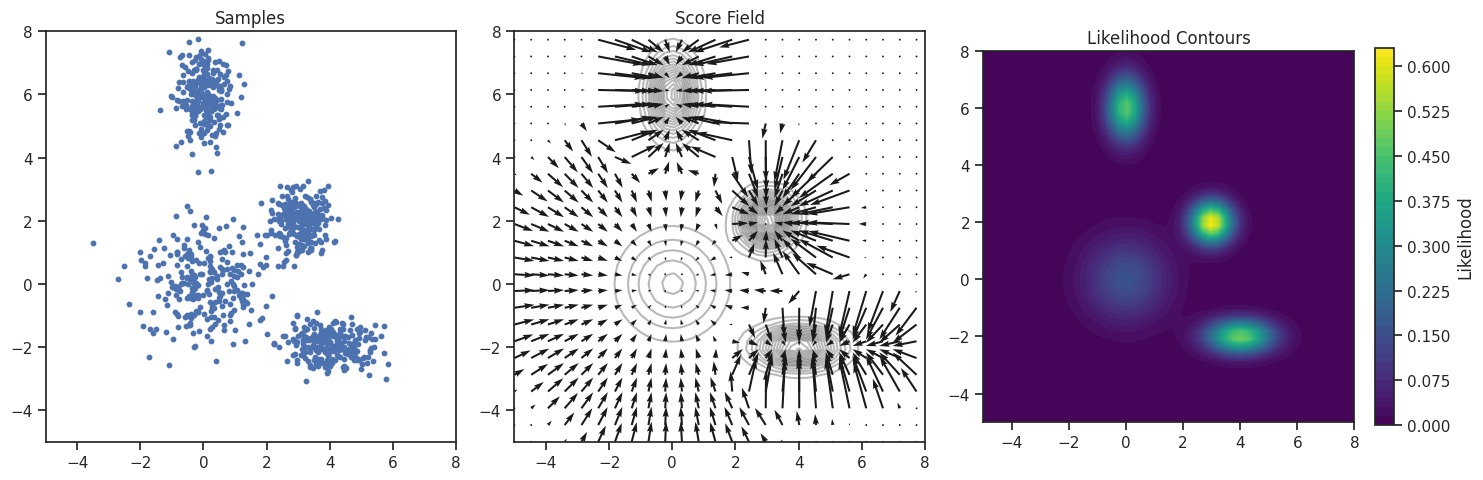

In [2]:
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

def visualize_gaussian_mixture_with_score(mixture, num_samples=1000, grid_size=50):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))

    # Create grid for visualization
    x = np.linspace(-5, 8, grid_size)
    y = np.linspace(-5, 8, grid_size)
    X, Y = np.meshgrid(x, y)
    points = np.column_stack([X.ravel(), Y.ravel()])

    # Compute likelihoods and scores
    likelihoods = mixture.likelihood(points)
    scores = mixture.score(points)
    samples = mixture.sample(num_samples)

    # Reshape for plotting
    likelihoods = likelihoods.reshape(grid_size, grid_size)
    scores_x = scores[:, 0].reshape(grid_size, grid_size)
    scores_y = scores[:, 1].reshape(grid_size, grid_size)

    ax1.scatter(samples[:, 0], samples[:, 1], s=10, alpha=1)
    ax1.set_title("Samples")

    skip = 2
    ax2.quiver(X[::skip, ::skip], Y[::skip, ::skip],
               scores_x[::skip, ::skip], scores_y[::skip, ::skip],
               scale=100, width=0.005)

    # Add likelihood contours to score plot for reference
    ax2.contour(X, Y, likelihoods, levels=20, colors='k', alpha=0.3)
    ax2.set_title("Score Field")

    # Plot likelihood contours
    contour = ax3.contourf(X, Y, likelihoods, levels=50, cmap='viridis')
    ax3.set_title("Likelihood Contours")
    plt.colorbar(contour, ax=ax3, label='Likelihood', fraction=0.046)

    # Plot score field
    # Subsample the grid for clearer arrows


    # Set consistent limits and labels
    for ax in [ax1, ax2, ax3]:
        ax.set_xlim(-5, 8)
        ax.set_ylim(-5, 8)
        ax.set_aspect('equal')
        ax.set_xlabel("")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

parameters = [
    {"mean": [0, 0], "std": [1, 1]},
    {"mean": [3, 2], "std": [0.5, 0.5]},
    {"mean": [0,6], "std": [0.45,0.75]},
    {"mean": [4,-2], "std": [0.8,0.4]},
]
mixture = GaussianMixture(parameters)
visualize_gaussian_mixture_with_score(mixture)

## Define Score Network and Dataset

In [3]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class ScoreNetwork(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        return self.net(x)

class DenoisingScoreMatchingDataset(Dataset):
    def __init__(self, gaussian_mixture, num_samples=10000, sigma=0.1):
        self.samples = torch.FloatTensor(gaussian_mixture.sample(num_samples))
        self.sigma = sigma

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x = self.samples[idx]

        noise = torch.randn_like(x) * self.sigma
        x_noisy = x + noise

        return x_noisy, noise, x

## Training

In [8]:
import torch
from torch import optim

def train_score_network(model, train_loader, num_epochs=100, sigma=0.1, device='cpu'):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0
        for batch_idx, (x_noisy, noise, x_clean) in enumerate(train_loader):
            x_noisy, noise = x_noisy.to(device), noise.to(device)

            optimizer.zero_grad()

            pred_score = model(x_noisy)
            target_score = -noise / (sigma**2)
            loss = torch.mean(torch.sum((pred_score - target_score)**2, dim=1))

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}')

    return losses

# Create dataset and dataloader
dataset = DenoisingScoreMatchingDataset(mixture, num_samples=30000, sigma=0.1)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Initialize and train the model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
score_net = ScoreNetwork().to(device)

losses = train_score_network(score_net, dataloader, num_epochs=300, device=device)

Epoch 10/300, Loss: 195.2431
Epoch 20/300, Loss: 195.5319
Epoch 30/300, Loss: 196.2061
Epoch 40/300, Loss: 194.0104
Epoch 50/300, Loss: 194.8174
Epoch 60/300, Loss: 193.0925
Epoch 70/300, Loss: 194.9726
Epoch 80/300, Loss: 196.0628
Epoch 90/300, Loss: 194.2378
Epoch 100/300, Loss: 194.1321
Epoch 110/300, Loss: 194.4911
Epoch 120/300, Loss: 195.0560
Epoch 130/300, Loss: 196.5980
Epoch 140/300, Loss: 195.6045
Epoch 150/300, Loss: 193.6821
Epoch 160/300, Loss: 195.9921
Epoch 170/300, Loss: 193.6341
Epoch 180/300, Loss: 194.9736
Epoch 190/300, Loss: 192.6714
Epoch 200/300, Loss: 195.6303
Epoch 210/300, Loss: 193.7541
Epoch 220/300, Loss: 194.5860
Epoch 230/300, Loss: 196.0935
Epoch 240/300, Loss: 192.4291
Epoch 250/300, Loss: 197.4806
Epoch 260/300, Loss: 192.5425
Epoch 270/300, Loss: 194.3506
Epoch 280/300, Loss: 193.5587
Epoch 290/300, Loss: 193.0369
Epoch 300/300, Loss: 193.0910


## Compare Learned and Reference Scores

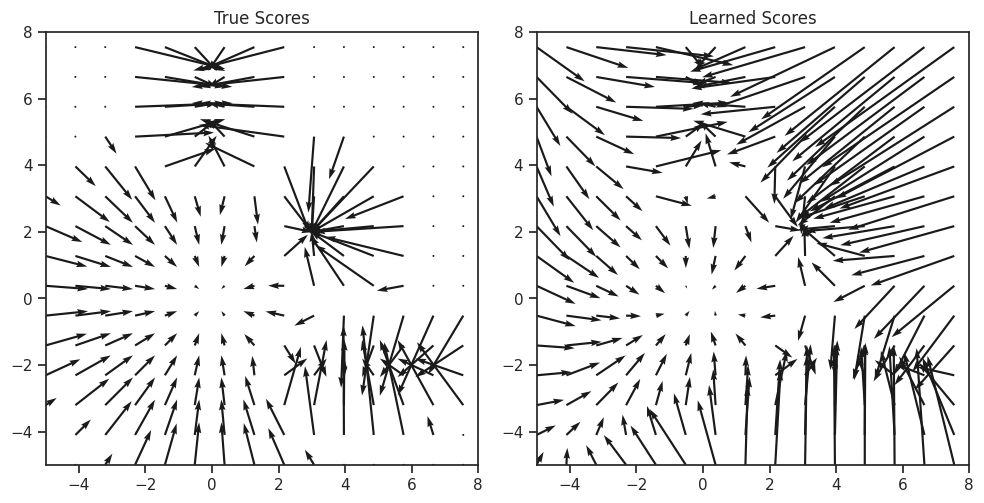

In [9]:
# Visualization function for learned scores
def visualize_learned_scores(mixture, score_net, grid_size=30, device='cpu'):
    """
    Visualize true and learned scores side by side
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # Create grid for visualization
    x = np.linspace(-5, 8, grid_size)
    y = np.linspace(-5, 8, grid_size)
    X, Y = np.meshgrid(x, y)
    points = np.column_stack([X.ravel(), Y.ravel()])

    # Compute true scores
    true_scores = mixture.score(points)
    true_scores_x = true_scores[:, 0].reshape(grid_size, grid_size)
    true_scores_y = true_scores[:, 1].reshape(grid_size, grid_size)

    # Compute learned scores
    score_net.eval()
    with torch.no_grad():
        learned_scores = score_net(torch.FloatTensor(points).to(device)).cpu().numpy()
    learned_scores_x = learned_scores[:, 0].reshape(grid_size, grid_size)
    learned_scores_y = learned_scores[:, 1].reshape(grid_size, grid_size)

    # Plot true scores
    skip = 2
    ax1.quiver(X[::skip, ::skip], Y[::skip, ::skip],
               true_scores_x[::skip, ::skip], true_scores_y[::skip, ::skip],
               scale=50, width=0.005)
    ax1.set_title("True Scores")

    # Plot learned scores
    ax2.quiver(X[::skip, ::skip], Y[::skip, ::skip],
               learned_scores_x[::skip, ::skip], learned_scores_y[::skip, ::skip],
               scale=50, width=0.005)
    ax2.set_title("Learned Scores")

    # Set consistent limits and labels
    for ax in [ax1, ax2]:
        ax.set_xlim(-5, 8)
        ax.set_ylim(-5, 8)
        ax.set_aspect('equal')
        ax.set_xlabel("")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

# Visualize the results
visualize_learned_scores(mixture, score_net, device=device)

## Langevin Dynamics

In [18]:
def langevin_dynamics(score_net, n_steps=1000, n_samples=35, step_size=0.01):

    device = next(score_net.parameters()).device

    x = torch.linspace(-5, 8, n_samples)
    y = torch.linspace(-5, 10, n_samples)
    X, Y = torch.meshgrid(x, y)
    x = torch.stack([X.flatten(), Y.flatten()], dim=1)

    x = x.to(device)

    trajectory = [x.cpu().detach().numpy()]

    score_net.eval()
    with torch.no_grad():
        for step in range(n_steps):

            score = score_net(x)
            noise = torch.randn_like(x)
            x = x + step_size * score + np.sqrt(2 * step_size) * noise

            if step in [0, 100, 200, 300, 400, 500]:
                trajectory.append(x.cpu().detach().numpy())

    return trajectory


trajectory = langevin_dynamics(
    score_net,
    n_steps=501,    # run for 501 steps to include step 500
    n_samples=35,
    step_size=0.01,
)

samples =  trajectory[-1]

## Visualize the Trajectories

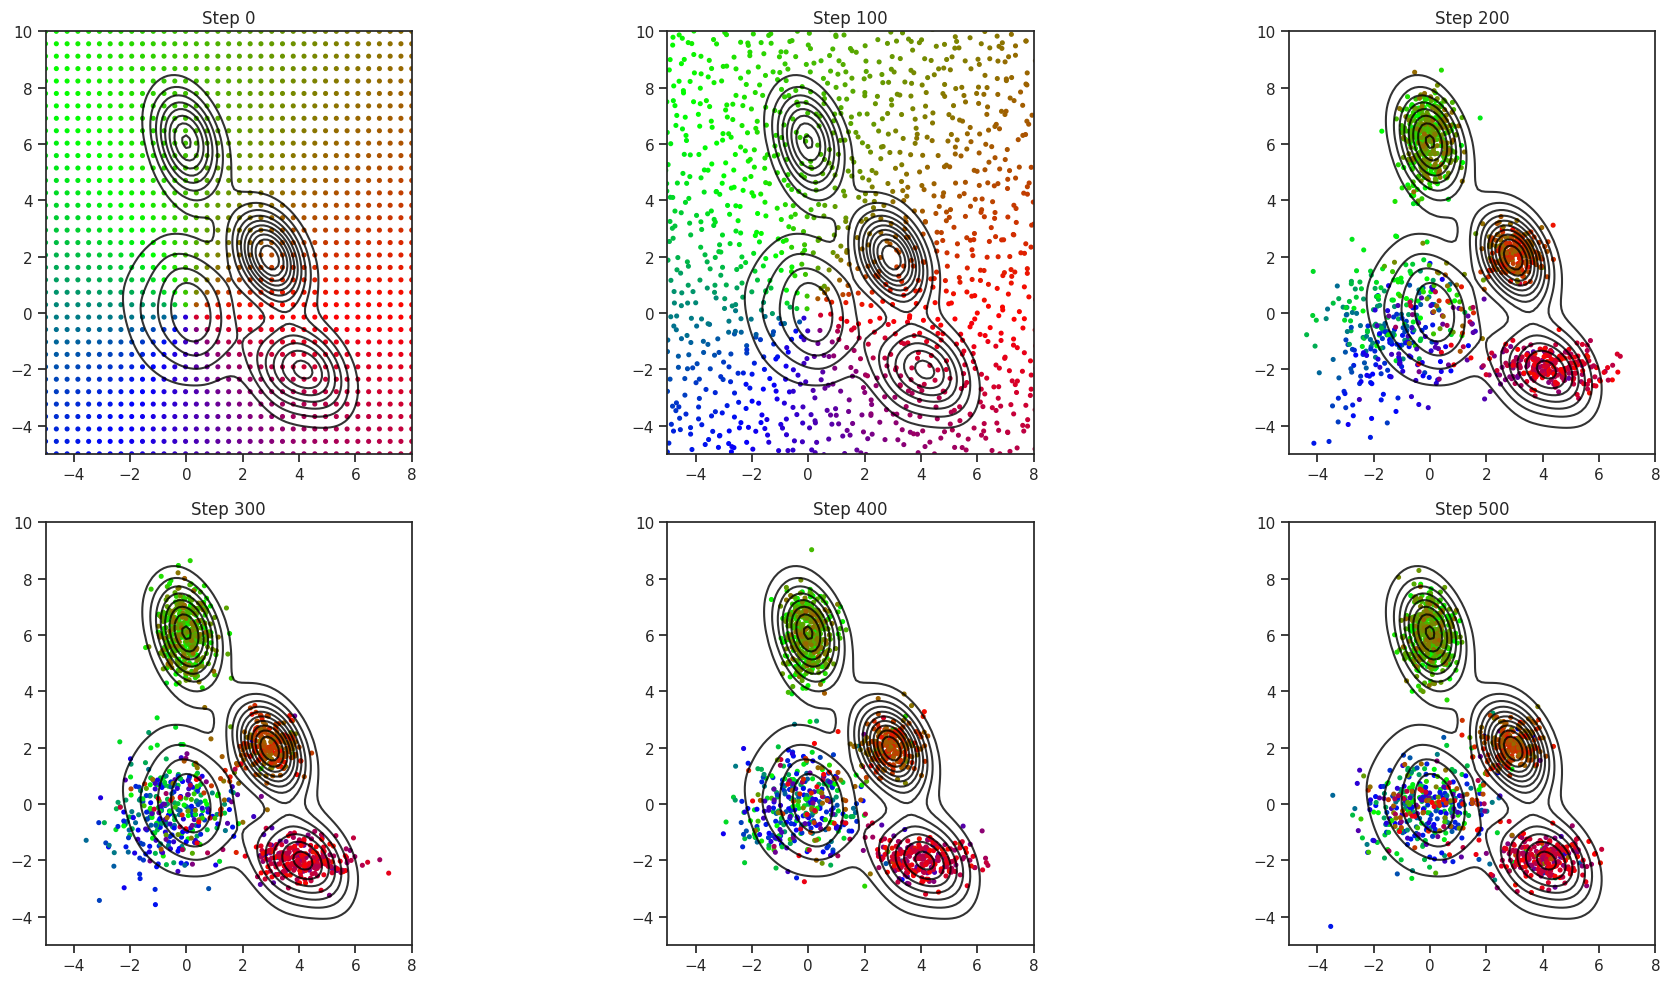

In [19]:
def get_angle_colors(positions):
    angles = np.arctan2(positions[:, 1], positions[:, 0])
    angles_deg = (np.degrees(angles) + 360) % 360
    colors = np.zeros((len(positions), 3))
    for i, angle in enumerate(angles_deg):
        segment = int(angle / 120)
        local_angle = angle - segment * 120
        if segment == 0:    # 0 degrees to 120 degrees (R->G)
            colors[i] = [1 - local_angle/120, local_angle/120, 0]
        elif segment == 1:  # 120 degrees to 240 degrees (G->B)
            colors[i] = [0, 1 - local_angle/120, local_angle/120]
        else:               # 240 degrees to 360° (B->R)
            colors[i] = [local_angle/120, 0, 1 - local_angle/120]

    return colors

def visualize_langevin_trajectory(trajectory, mixture, figsize=(20, 10)):

    n_plots = len(trajectory)
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()
    real_samples = mixture.sample(1000)
    from scipy.stats import gaussian_kde
    xx, yy = np.mgrid[-5:8:100j, -5:10:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    kernel = gaussian_kde(real_samples.T)
    density = np.reshape(kernel(positions).T, xx.shape)

    steps = [0, 100, 200, 300, 400, 500]

    for idx, (samples, step) in enumerate(zip(trajectory, steps)):
        ax = axes[idx]

        if idx == 0:
            c = get_angle_colors(samples)

        ax.contour(xx, yy, density, levels=10, alpha=0.8, colors='black')
        ax.scatter(samples[:, 0], samples[:, 1], alpha=1, s=7, color=c)

        ax.set_xlim(-5, 8)
        ax.set_ylim(-5, 10)
        ax.set_aspect('equal')
        ax.set_title(f'Step {step}')

    plt.tight_layout()
    plt.show()

visualize_langevin_trajectory(trajectory, mixture)

## Annealed Langevin Dynamics

## Network and Dataset Definition with Noise Level

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class ScoreNetworkWithSigma(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, hidden_dim),  # +1 for sigma
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x, sigma):
        sigma = sigma.view(-1, 1)
        x_sigma = torch.cat([x, sigma], dim=1)
        return self.net(x_sigma)

class AnnealedDenoisingScoreMatchingDataset(Dataset):
    def __init__(self, gaussian_mixture, num_samples=10000, sigmas=[4.0, 2.0, 1.0, 0.5, 0.2, 0.01]):
        self.samples = torch.FloatTensor(gaussian_mixture.sample(num_samples))
        self.sigmas = sigmas

    def __len__(self):
        return len(self.samples) * len(self.sigmas)

    def __getitem__(self, idx):
        sample_idx = idx // len(self.sigmas)
        sigma_idx = idx % len(self.sigmas)

        x = self.samples[sample_idx]
        sigma = self.sigmas[sigma_idx]

        # Add noise to the sample
        noise = torch.randn_like(x) * sigma
        x_noisy = x + noise

        return x_noisy, noise, x, torch.tensor(sigma).float()

## Training

In [21]:
def train_annealed_score_network(model, train_loader, num_epochs=100, device='cpu'):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0
        for batch_idx, (x_noisy, noise, x_clean, sigma) in enumerate(train_loader):
            x_noisy, noise = x_noisy.to(device), noise.to(device)
            sigma = sigma.to(device)

            optimizer.zero_grad()

            pred_score = model(x_noisy, sigma)

            target_score = -noise / (sigma.view(-1, 1) ** 2)
            loss = torch.mean(torch.sum((pred_score - target_score) ** 2, dim=1))

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}')

    return losses

sigmas = [4.0, 2.0, 1.0, 0.5, 0.2, 0.01]

dataset = AnnealedDenoisingScoreMatchingDataset(mixture, num_samples=10000, sigmas=sigmas)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
score_net = ScoreNetworkWithSigma().to(device)

losses = train_annealed_score_network(score_net, dataloader, num_epochs=100, device=device)

Epoch 10/100, Loss: 3336.3308
Epoch 20/100, Loss: 3325.5509
Epoch 30/100, Loss: 3309.1140
Epoch 40/100, Loss: 3340.3801
Epoch 50/100, Loss: 3306.2558
Epoch 60/100, Loss: 3376.0421
Epoch 70/100, Loss: 3324.7295
Epoch 80/100, Loss: 3320.3568
Epoch 90/100, Loss: 3299.8190
Epoch 100/100, Loss: 3295.1339


## Visualization of Trajectories

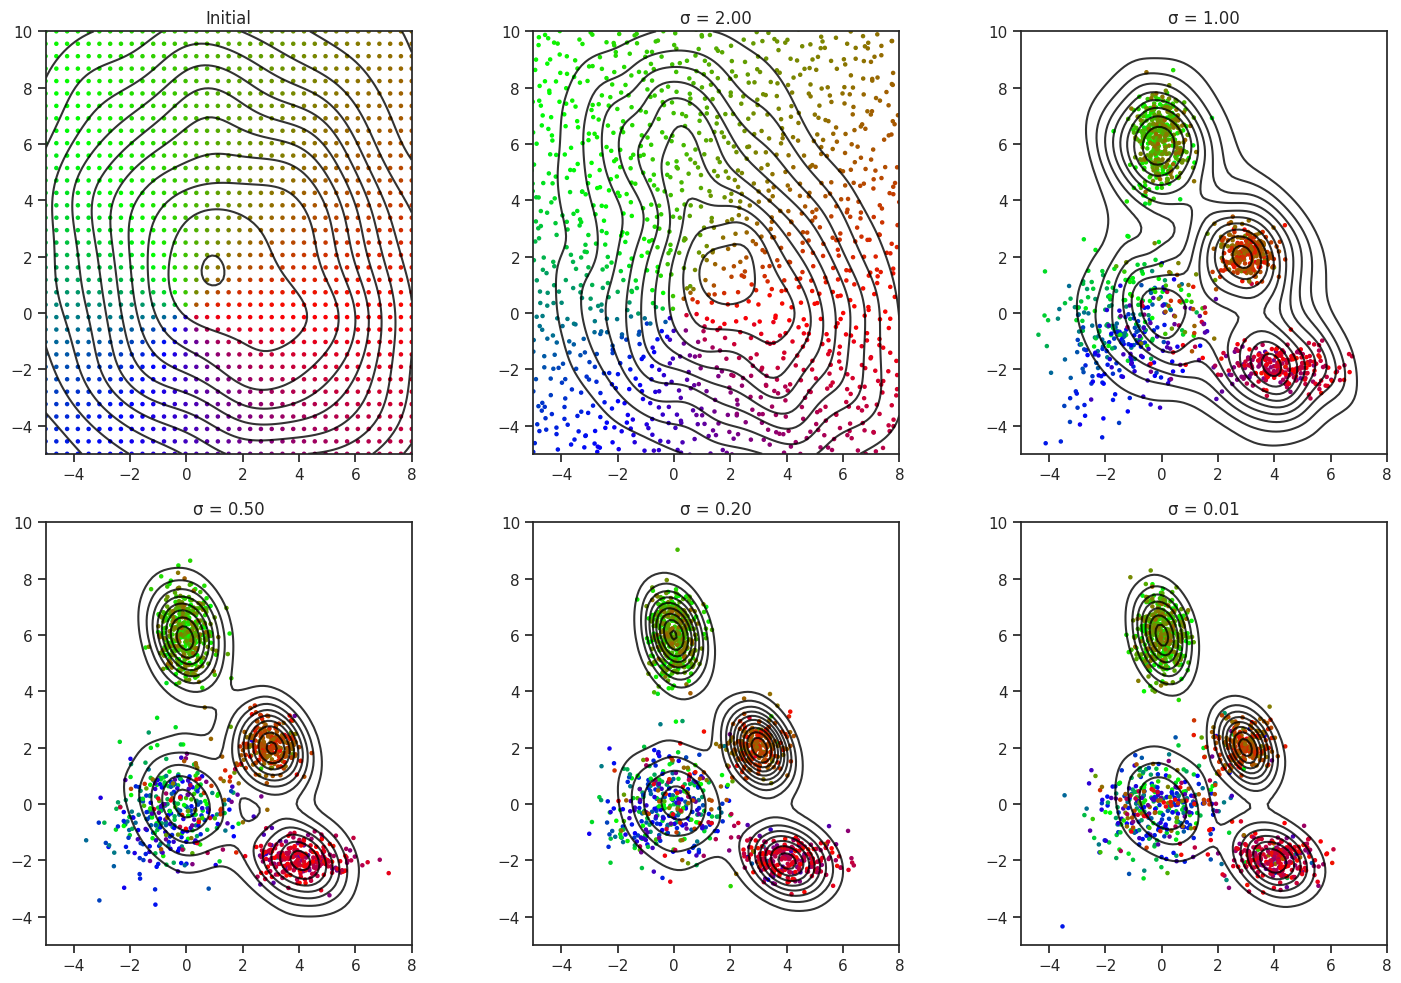

In [22]:
def visualize_annealed_langevin_trajectory(trajectory, mixture, sigmas, figsize=(15, 10)):

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()

    from scipy.stats import gaussian_kde
    xx, yy = np.mgrid[-5:8:100j, -5:10:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])

    for idx, (samples, sigma) in enumerate(zip(trajectory, sigmas)):
        ax = axes[idx]

        if idx == 0:
            c = get_angle_colors(samples)

        real_samples = torch.tensor(mixture.sample(5000))
        real_samples += torch.randn_like(real_samples) * sigma

        kernel = gaussian_kde(real_samples.T)
        density = np.reshape(kernel(positions).T, xx.shape)

        ax.contour(xx, yy, density, levels=10, alpha=0.8, colors='black')

        ax.scatter(samples[:, 0], samples[:, 1], alpha=1.0, s=5, color=c)

        ax.set_xlim(-5, 8)
        ax.set_ylim(-5, 10)
        ax.set_aspect('equal')
        ax.set_title(f'σ = {sigma:.2f}' if idx > 0 else 'Initial')

    plt.tight_layout()
    plt.show()

visualize_annealed_langevin_trajectory(trajectory, mixture, sigmas)